# Исследование влияния числа точек коллокации, граничных и начальных условий

---

## Схема эксперимента

`n_boundary` и `n_initial` масштабируются **пропорционально** `n_collocation` через коэффициенты:

```
n_boundary = boundary_ratio × n_collocation   (по умолчанию 0.2)
n_initial  = initial_ratio  × n_collocation   (по умолчанию 0.2)
```

| Параметр | Значения |
|---|---|
| `n_collocation` | 500, 1000, 2000, 4000, 6000, 8000, 12000, 16000 |
| `n_boundary` | 0.2 × n_col (авто) |
| `n_initial` | 0.2 × n_col (авто) |
| `n_observations` | 900 (фиксировано) |



In [1]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import time
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Импорты — OK')

Импорты — OK


In [2]:
from pinn_module_final import (
    make_consistent_config,
    prepare_config,
    build_solution_grid,
    generate_observations,
    generate_collocation_points,
    generate_boundary_points,
    PINN_Source,
    train_adam,
    train_lbfgs,
    evaluate_model,
    device,
)

print(f'Ядро загружено. Устройство: {device}')

Устройство: cuda
run_experiment — OK
Ядро загружено. Устройство: cuda


In [3]:
import os

OUT_DIR = r"D:\PINN_VKR\npts_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
FIXED_N_OBS = 900
FIXED_NOISE = 0.001
PRINT_EVERY = 2000
EVAL_EVERY  = 1000

SAMPLING_COEFFICIENTS = {
    'boundary_ratio': 0.2,
    'initial_ratio':  0.2,
    'min_boundary':   2,
    'min_initial':    2,
}

N_COLLOCATION_LIST = [500, 1000, 2000, 4000, 6000, 8000, 12000, 15000]

TASK_DEFS = {
    'Тест 1: Heat N+N': dict(
        u_exact       = lambda x, t: np.cos(np.pi * x) * np.exp(-t),
        pde_type      = 'heat',
        pde_kwargs    = {'k': 0.3},
        bc_left_type  = 'neumann',
        bc_right_type = 'neumann',
        epochs        = 10000,
    ),
    'Тест 2: Heat D+D': dict(
        u_exact       = lambda x, t: np.sin(np.pi * x) * np.cos(2 * np.pi * t),
        pde_type      = 'heat',
        pde_kwargs    = {'k': 0.3},
        bc_left_type  = 'dirichlet',
        bc_right_type = 'dirichlet',
        epochs        = 10000,
    ),
    'Тест 8: Advection-Diffusion': dict(
        u_exact       = lambda x, t: np.exp(-t) * np.sin(np.pi * x),
        pde_type      = 'advection_diffusion',
        pde_kwargs    = {'k': 0.1, 'v': 0.5},
        bc_left_type  = 'dirichlet',
        bc_right_type = 'dirichlet',
        epochs        = 10000,
    ),
}

TASK_COLORS = {
    'Тест 1: Heat N+N':             '#2563eb',
    'Тест 2: Heat D+D': '#dc2626',
    'Тест 8: Advection-Diffusion':  '#16a34a',
}

TASK_MARKERS = {
    'Тест 1: Heat N+N':             'o',
    'Тест 2: Heat D+D': 's',
    'Тест 8: Advection-Diffusion':  '^',
}

CKPT_FILE = os.path.join(OUT_DIR, 'checkpoint.json')


def get_bc_ic_counts(n_col):
    """Возвращает n_boundary и n_initial пропорционально n_collocation."""
    n_b = max(SAMPLING_COEFFICIENTS['min_boundary'],
              int(round(SAMPLING_COEFFICIENTS['boundary_ratio'] * n_col)))
    n_i = max(SAMPLING_COEFFICIENTS['min_initial'],
              int(round(SAMPLING_COEFFICIENTS['initial_ratio']  * n_col)))
    return n_b, n_i


sampling_plan = []
for n_col in N_COLLOCATION_LIST:
    n_b, n_i = get_bc_ic_counts(n_col)
    sampling_plan.append({
        'n_collocation':      n_col,
        'n_boundary':         n_b,
        'n_initial':          n_i,
        'constraints_total':  2 * n_b + n_i,
        'bc_ratio':   round(n_b / n_col, 3),
        'ic_ratio':   round(n_i / n_col, 3),
    })
sampling_df = pd.DataFrame(sampling_plan)

print(f'Задачи: {list(TASK_DEFS.keys())}')
print(f'n_collocation: {N_COLLOCATION_LIST}')
print(f'n_boundary = {SAMPLING_COEFFICIENTS["boundary_ratio"]} x n_col')
print(f'n_initial  = {SAMPLING_COEFFICIENTS["initial_ratio"]}  x n_col')
print(f'Всего запусков: {len(TASK_DEFS) * len(N_COLLOCATION_LIST)}')
print(f'Результаты -> {OUT_DIR}\n')
display(sampling_df)

Задачи: ['Тест 1: Heat N+N', 'Тест 2: Heat D+D', 'Тест 8: Advection-Diffusion']
n_collocation: [500, 1000, 2000, 4000, 6000, 8000, 12000, 15000]
n_boundary = 0.2 x n_col
n_initial  = 0.2  x n_col
Всего запусков: 24
Результаты -> D:\PINN_VKR\npts_analysis



,n_collocation,n_boundary,n_initial,constraints_total,bc_ratio,ic_ratio
0,500,100,100,300,0.2,0.2
1,1000,200,200,600,0.2,0.2
2,2000,400,400,1200,0.2,0.2
3,4000,800,800,2400,0.2,0.2
4,6000,1200,1200,3600,0.2,0.2
5,8000,1600,1600,4800,0.2,0.2
6,12000,2400,2400,7200,0.2,0.2
7,15000,3000,3000,9000,0.2,0.2


In [ ]:
def run_npts_experiment(task_name, task_def, n_col, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    n_b, n_i = get_bc_ic_counts(n_col)

    cfg_raw = make_consistent_config(
        n_collocation  = n_col,
        n_boundary     = n_b,
        n_initial      = n_i,
        n_observations = FIXED_N_OBS,
        noise_level    = FIXED_NOISE,
        print_every    = PRINT_EVERY,
        eval_every     = EVAL_EVERY,
        **task_def,
    )
    cfg = prepare_config(cfg_raw)
    trn = cfg['training']
    dom = cfg['domain']

    x_grid, t_grid, U   = build_solution_grid(cfg)
    x_obs, t_obs, u_obs = generate_observations(x_grid, t_grid, U, cfg)
    x_col_t, t_col_t    = generate_collocation_points(cfg)
    boundary             = generate_boundary_points(cfg)

    data = {
        'x_obs': x_obs, 't_obs': t_obs, 'u_obs': u_obs,
        'x_col': x_col_t, 't_col': t_col_t, 'boundary': boundary,
    }

    model = PINN_Source(
        hidden_u   = trn['hidden_layers_u'],
        hidden_f   = trn['hidden_layers_f'],
        activation = trn['activation'],
        x_range    = dom['x_range'],
        t_range    = dom['t_range'],
    ).to(device)

    t0 = time.time()
    history, _ = train_adam(model, data, cfg)
    train_lbfgs(model, data, cfg)
    elapsed = time.time() - t0

    m  = evaluate_model(model, cfg, n_eval=80)
    mf = m['f']
    mu = m['u']

    return {
        'task':              task_name,
        'n_collocation':     n_col,
        'n_boundary':        n_b,
        'n_initial':         n_i,
        'constraints_total': 2 * n_b + n_i,
        'n_observations':    FIXED_N_OBS,
        'f_l2_rel':    mf['l2_rel'],
        'f_h1_rel':    mf['h1_rel'],
        'f_linf':      mf['linf'],
        'f_mae':       mf['mae'],
        'f_rmse':      mf['rmse'],

        'u_l2_rel':    mu['l2_rel'],
        'u_h1_rel':    mu['h1_rel'],
        'u_linf':      mu['linf'],
        'u_mae':       mu['mae'],
        'u_rmse':      mu['rmse'],

        'time_sec':    elapsed,
        'final_loss':  history['loss'][-1] if history['loss'] else None,
    }


def load_checkpoint(path):
    if os.path.isfile(path):
        with open(path) as f:
            data = json.load(f)
        print(f'Чекпоинт загружен: {len(data)} результатов ({path})')
        return data
    print('Чекпоинт не найден, начинаем с нуля.')
    return []


def save_checkpoint(path, data):
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)


print('run_npts_experiment — OK')

run_npts_experiment — OK


##  Основной цикл экспериментов


In [ ]:
import pandas as pd

raw_csv = os.path.join(OUT_DIR, 'npts_raw_results.csv')
df_all = pd.read_csv(raw_csv)

# Переименовываем задачи под новую нумерацию
df_all['task'] = df_all['task'].replace({
    'Тест 2: Heat N+N':             'Тест 1: Heat N+N',
    'Тест 4: Heat D+D oscillating': 'Тест 2: Heat D+D',
    'Тест 6: Advection-Diffusion':  'Тест 8: Advection-Diffusion',
})

print(f'✓ Загружено {len(df_all)} строк из {raw_csv}')
print(df_all[['task', 'n_collocation', 'f_l2_rel', 'u_l2_rel']].to_string(index=False))

✓ Загружено 24 строк из D:\PINN_VKR\npts_analysis\npts_raw_results.csv
                       task  n_collocation  f_l2_rel  u_l2_rel
           Тест 1: Heat N+N            500  0.019920  0.000729
           Тест 1: Heat N+N           1000  0.033424  0.001022
           Тест 1: Heat N+N           2000  0.030492  0.001003
           Тест 1: Heat N+N           4000  0.031529  0.000931
           Тест 1: Heat N+N           6000  0.027797  0.000823
           Тест 1: Heat N+N           8000  0.027904  0.000812
           Тест 1: Heat N+N          12000  0.027379  0.000766
           Тест 1: Heat N+N          15000  0.025550  0.000715
           Тест 2: Heat D+D            500  0.015277  0.001021
           Тест 2: Heat D+D           1000  0.015338  0.001047
           Тест 2: Heat D+D           2000  0.017734  0.001072
           Тест 2: Heat D+D           4000  0.014326  0.000927
           Тест 2: Heat D+D           6000  0.016895  0.000930
           Тест 2: Heat D+D           8000  0.0

##  Загрузка результатов (для повторного анализа без переобучения)

In [7]:
raw_csv = os.path.join(OUT_DIR, 'npts_raw_results.csv')
if 'df_all' not in dir() or df_all is None:
    assert os.path.isfile(raw_csv), f'Файл не найден: {raw_csv}'
    df_all = pd.read_csv(raw_csv)
    print(f'Загружено {len(df_all)} строк из {raw_csv}')
else:
    print(f'DataFrame уже в памяти: {len(df_all)} строк')

# Словарь DataFrame по задачам — используется во всех ячейках ниже
dfs = {
    task_name: df_all[df_all['task'] == task_name]
                .sort_values('n_collocation')
                .reset_index(drop=True)
    for task_name in TASK_DEFS
}

print('\nКраткая сводка:')
for task_name, df in dfs.items():
    print(f'  {task_name}: {len(df)} строк, '
          f'f_L2 min={df["f_l2_rel"].min()*100:.3f}% '
          f'max={df["f_l2_rel"].max()*100:.3f}%')

DataFrame уже в памяти: 24 строк

Краткая сводка:
  Тест 1: Heat N+N: 8 строк, f_L2 min=1.992% max=3.342%
  Тест 2: Heat D+D: 8 строк, f_L2 min=1.433% max=1.804%
  Тест 8: Advection-Diffusion: 8 строк, f_L2 min=3.068% max=3.373%


---
##  Сводная таблица — Тест 1 (Heat N+N)

In [8]:
DISPLAY_COLS = [
    'n_collocation', 'n_boundary', 'n_initial', 'constraints_total',
    'f_l2_rel', 'f_h1_rel', 
    'u_l2_rel', 'u_h1_rel', 
    'time_sec', 'final_loss',
]

def fmt_pct(x): return f'{x*100:.4f}%'

def make_summary_table(df):
    tbl = df[DISPLAY_COLS].copy()
    for c in ['f_l2_rel', 'f_h1_rel', 'u_l2_rel', 'u_h1_rel']:
        tbl[c] = df[c].apply(fmt_pct)
    tbl['time_sec']   = df['time_sec'].round(1)
    tbl['final_loss'] = df['final_loss'].apply(lambda x: f'{x:.2e}')
    return tbl.reset_index(drop=True)

task_name = 'Тест 1: Heat N+N'
print('='*80)
print(f'  {task_name}')
print('='*80)
display(make_summary_table(dfs[task_name]))
make_summary_table(dfs[task_name]).to_csv(
    os.path.join(OUT_DIR, 'table_test1.csv'), index=False)
print('-> table_test1.csv')

  Тест 1: Heat N+N


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,time_sec,final_loss
0,500,100,100,300,1.9920%,11.5879%,0.0729%,0.3030%,262.2,8.15e-05
1,1000,200,200,600,3.3424%,17.0062%,0.1022%,0.4337%,256.6,1.03e-04
2,2000,400,400,1200,3.0492%,15.9696%,0.1003%,0.4111%,251.7,1.09e-04
3,4000,800,800,2400,3.1529%,16.5141%,0.0931%,0.3942%,260.4,1.01e-04
4,6000,1200,1200,3600,2.7797%,14.9565%,0.0823%,0.3554%,258.0,8.66e-05
5,8000,1600,1600,4800,2.7904%,14.9971%,0.0812%,0.3460%,257.4,8.13e-05
6,12000,2400,2400,7200,2.7379%,15.2652%,0.0766%,0.3357%,266.5,8.91e-05
7,15000,3000,3000,9000,2.5550%,14.5073%,0.0715%,0.3087%,288.0,9.79e-05


-> table_test1.csv


##  Сводная таблица — Тест 2 (Heat D+D)

In [9]:
task_name = 'Тест 2: Heat D+D'
print('='*80)
print(f'  {task_name}')
print('='*80)
display(make_summary_table(dfs[task_name]))
make_summary_table(dfs[task_name]).to_csv(
    os.path.join(OUT_DIR, 'table_test2.csv'), index=False)
print('-> table_test2.csv')

  Тест 2: Heat D+D


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,time_sec,final_loss
0,500,100,100,300,1.5277%,5.6432%,0.1021%,0.4603%,356.0,7.92e-04
1,1000,200,200,600,1.5338%,5.4700%,0.1047%,0.4310%,352.8,7.51e-04
2,2000,400,400,1200,1.7734%,6.0995%,0.1072%,0.4851%,357.8,7.61e-04
3,4000,800,800,2400,1.4326%,5.4061%,0.0927%,0.4142%,363.0,7.69e-04
4,6000,1200,1200,3600,1.6895%,5.9165%,0.0930%,0.4123%,352.8,7.04e-04
5,8000,1600,1600,4800,1.8043%,5.9964%,0.1032%,0.4160%,356.6,8.64e-04
6,12000,2400,2400,7200,1.7279%,6.0650%,0.0989%,0.4386%,370.0,7.18e-04
7,15000,3000,3000,9000,1.7094%,6.0011%,0.0943%,0.4056%,394.3,8.19e-04


-> table_test2.csv


##  Сводная таблица — Тест 8 (Advection-Diffusion)

In [10]:
task_name = 'Тест 8: Advection-Diffusion'
print('='*80)
print(f'  {task_name}')
print('='*80)
display(make_summary_table(dfs[task_name]))
make_summary_table(dfs[task_name]).to_csv(
    os.path.join(OUT_DIR, 'table_test8.csv'), index=False)
print('-> table_test8.csv')

  Тест 8: Advection-Diffusion


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,time_sec,final_loss
0,500,100,100,300,3.3128%,16.1309%,0.1279%,0.6358%,207.8,2.42e-05
1,1000,200,200,600,3.2500%,16.2819%,0.1316%,0.6259%,206.5,2.49e-05
2,2000,400,400,1200,3.2784%,16.0577%,0.1297%,0.6344%,208.2,2.57e-05
3,4000,800,800,2400,3.3522%,16.5693%,0.1395%,0.6654%,206.4,2.32e-05
4,6000,1200,1200,3600,3.0684%,15.3244%,0.1218%,0.5922%,209.4,2.46e-05
5,8000,1600,1600,4800,3.2827%,16.4510%,0.1310%,0.6290%,205.7,2.34e-05
6,12000,2400,2400,7200,3.3279%,16.5523%,0.1389%,0.6701%,212.6,2.29e-05
7,15000,3000,3000,9000,3.3733%,16.5669%,0.1427%,0.6897%,225.8,2.29e-05


-> table_test8.csv


---
## Сводный график: все задачи 

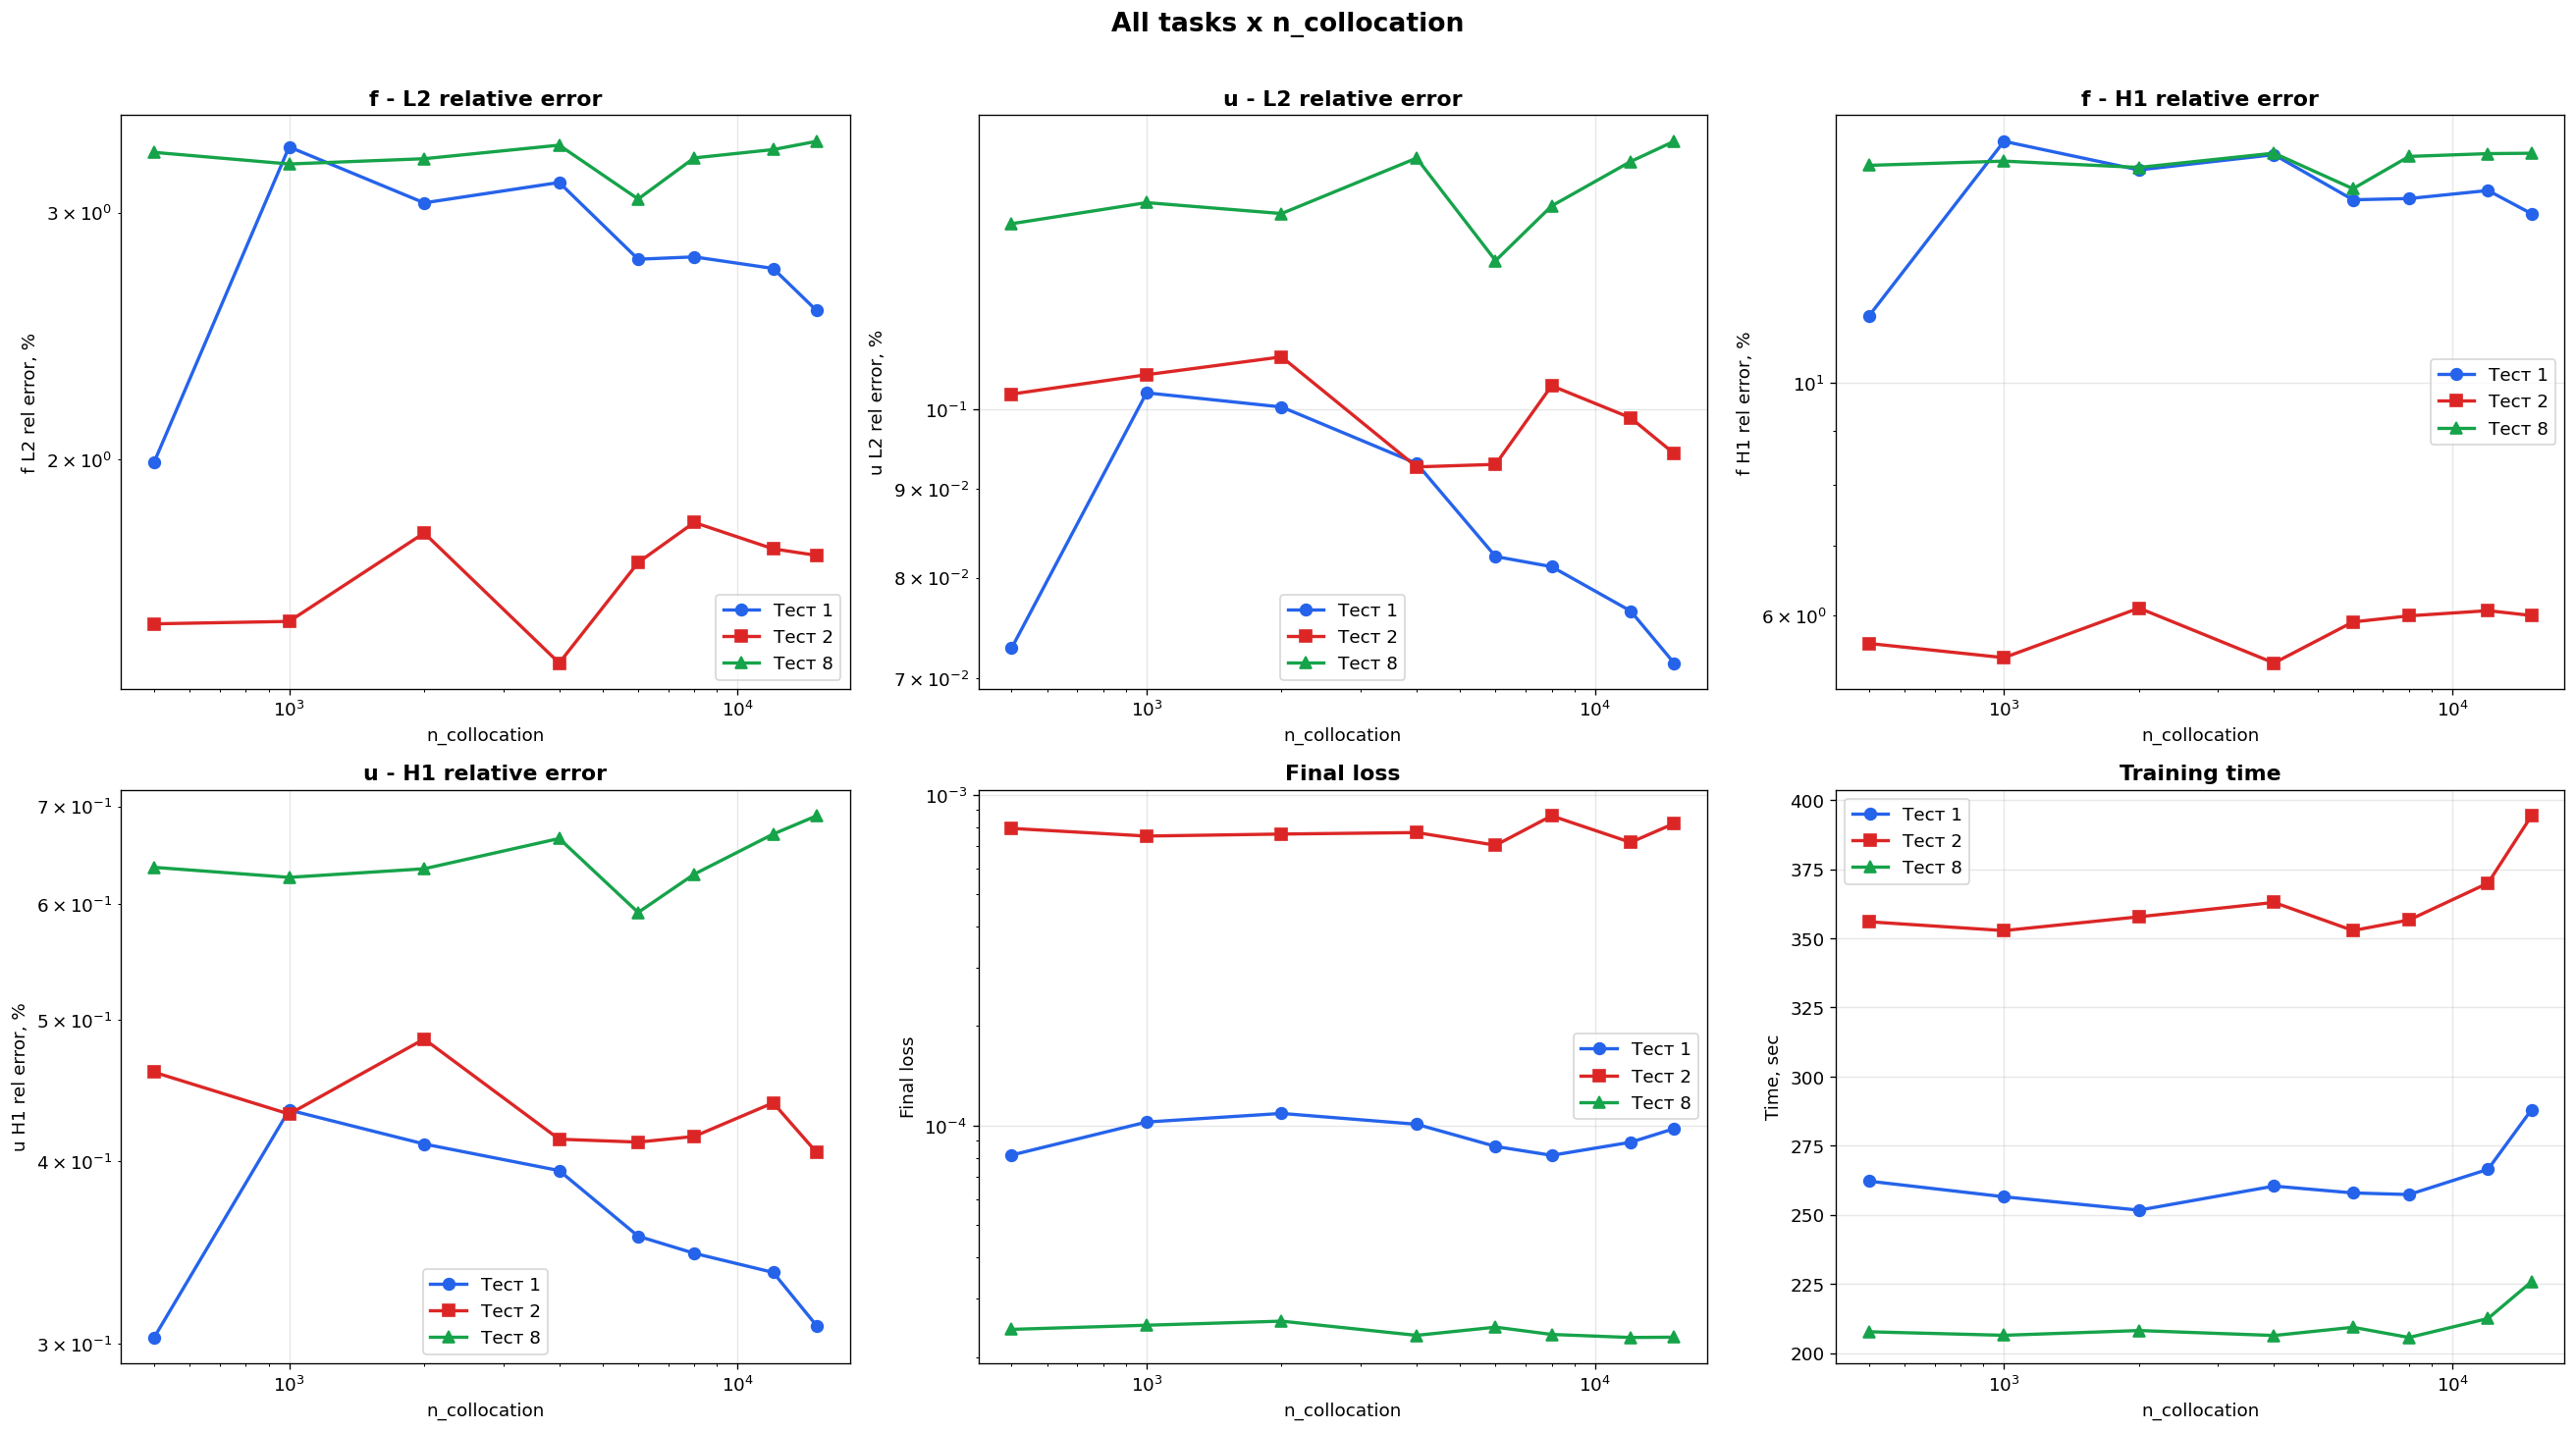

-> summary_all_tasks.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

panels = [
    (axes[0, 0], 'f_l2_rel',   'f L2 rel error, %', 'f - L2 relative error',  True,  True),
    (axes[0, 1], 'u_l2_rel',   'u L2 rel error, %', 'u - L2 relative error',  True,  True),
    (axes[0, 2], 'f_h1_rel',   'f H1 rel error, %', 'f - H1 relative error',  True,  True),
    (axes[1, 0], 'u_h1_rel',   'u H1 rel error, %', 'u - H1 relative error',  True,  True),
    (axes[1, 1], 'final_loss', 'Final loss',         'Final loss',             True,  True),
    (axes[1, 2], 'time_sec',   'Time, sec',          'Training time',          True,  False),
]

for ax, metric, ylabel, title, xlog, ylog in panels:
    for task_name, df in dfs.items():
        short = task_name.split(':')[0].strip()
        y = df[metric].values * (100 if 'rel' in metric else 1)
        ax.plot(df['n_collocation'], y,
                f'{TASK_MARKERS[task_name]}-',
                color=TASK_COLORS[task_name],
                linewidth=2, markersize=7, label=short)
    ax.set_xlabel('n_collocation')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    if xlog: ax.set_xscale('log')
    if ylog: ax.set_yscale('log')
    ax.legend()

plt.suptitle('All tasks x n_collocation',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'summary_all_tasks.png'), bbox_inches='tight', dpi=130)
plt.show()
print('-> summary_all_tasks.png')

---
## Топ-5 лучших и худших по каждой задаче

In [13]:
TOP_N    = 5
TOP_COLS = [
    'n_collocation', 'n_boundary', 'n_initial', 'constraints_total',
    'f_l2_rel', 'f_h1_rel', 
    'u_l2_rel', 'time_sec',
]

def format_top_df(df_sub):
    d = df_sub[TOP_COLS].copy()
    for c in ['f_l2_rel', 'f_h1_rel', 'u_l2_rel']:
        d[c] = (d[c] * 100).round(4).astype(str) + '%'
    d['time_sec']    = d['time_sec'].round(1)
    return d.reset_index(drop=True)

best_all, worst_all = [], []

for task_name, df in dfs.items():
    df_sorted = df.sort_values('f_l2_rel').reset_index(drop=True)
    best  = format_top_df(df_sorted.head(TOP_N))
    worst = format_top_df(
        df_sorted.tail(TOP_N).sort_values('f_l2_rel', ascending=False))

    print(f'\n{"="*90}')
    print(f'  {task_name}')
    print(f'{"="*90}')
    print(f'\n  TOP-{TOP_N} best (min f L2):')
    display(best)
    print(f'\n  TOP-{TOP_N} worst (max f L2):')
    display(worst)

    best_all.append(best)
    worst_all.append(worst)

pd.concat(best_all,  ignore_index=True).to_csv(
    os.path.join(OUT_DIR, 'top5_best.csv'),  index=False)
pd.concat(worst_all, ignore_index=True).to_csv(
    os.path.join(OUT_DIR, 'top5_worst.csv'), index=False)
print('\n-> top5_best.csv  /  top5_worst.csv')


  Тест 1: Heat N+N

  TOP-5 best (min f L2):


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,time_sec
0,500,100,100,300,1.992%,11.5879%,0.0729%,262.2
1,15000,3000,3000,9000,2.555%,14.5073%,0.0715%,288.0
2,12000,2400,2400,7200,2.7379%,15.2652%,0.0766%,266.5
3,6000,1200,1200,3600,2.7797%,14.9565%,0.0823%,258.0
4,8000,1600,1600,4800,2.7904%,14.9971%,0.0812%,257.4



  TOP-5 worst (max f L2):


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,time_sec
0,1000,200,200,600,3.3424%,17.0062%,0.1022%,256.6
1,4000,800,800,2400,3.1529%,16.5141%,0.0931%,260.4
2,2000,400,400,1200,3.0492%,15.9696%,0.1003%,251.7
3,8000,1600,1600,4800,2.7904%,14.9971%,0.0812%,257.4
4,6000,1200,1200,3600,2.7797%,14.9565%,0.0823%,258.0



  Тест 2: Heat D+D

  TOP-5 best (min f L2):


...


  Тест 8: Advection-Diffusion

  TOP-5 best (min f L2):


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,time_sec
0,6000,1200,1200,3600,3.0684%,15.3244%,0.1218%,209.4
1,1000,200,200,600,3.25%,16.2819%,0.1316%,206.5
2,2000,400,400,1200,3.2784%,16.0577%,0.1297%,208.2
3,8000,1600,1600,4800,3.2827%,16.451%,0.131%,205.7
4,500,100,100,300,3.3128%,16.1309%,0.1279%,207.8



  TOP-5 worst (max f L2):


,n_collocation,n_boundary,n_initial,constraints_total,f_l2_rel,f_h1_rel,u_l2_rel,time_sec
0,15000,3000,3000,9000,3.3733%,16.5669%,0.1427%,225.8
1,4000,800,800,2400,3.3522%,16.5693%,0.1395%,206.4
2,12000,2400,2400,7200,3.3279%,16.5523%,0.1389%,212.6
3,500,100,100,300,3.3128%,16.1309%,0.1279%,207.8
4,8000,1600,1600,4800,3.2827%,16.451%,0.131%,205.7



-> top5_best.csv  /  top5_worst.csv


---
##  Ранжированные барчарты

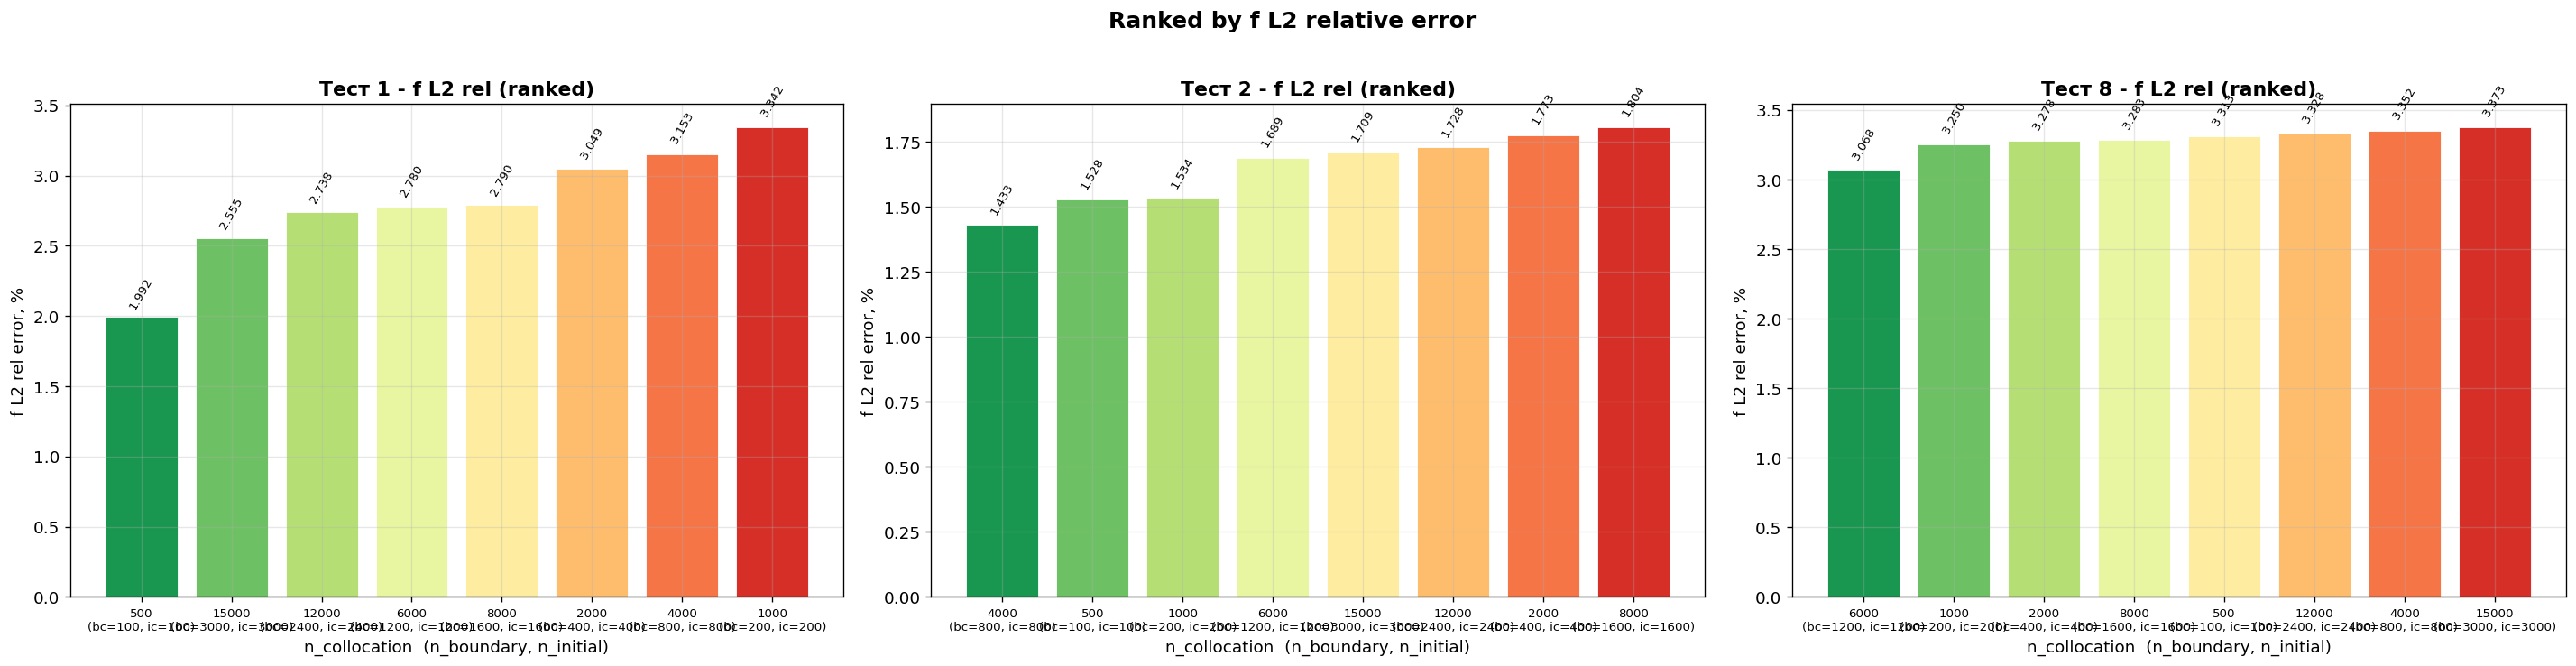

-> barchart_f_l2.png


In [14]:
fig, axes = plt.subplots(1, len(TASK_DEFS), figsize=(8 * len(TASK_DEFS), 6))

for ax, (task_name, df) in zip(axes, dfs.items()):
    df_s   = df.sort_values('f_l2_rel').reset_index(drop=True)
    n      = len(df_s)
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, n))
    bars   = ax.bar(range(n), df_s['f_l2_rel'].values * 100,
                    color=colors, edgecolor='white', lw=0.5)

    for bar, v in zip(bars, df_s['f_l2_rel'].values * 100):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=8, rotation=60)

    ax.set_xticks(range(n))
    ax.set_xticklabels(
        [f"{int(r['n_collocation'])}\n(bc={int(r['n_boundary'])}, ic={int(r['n_initial'])})"
         for _, r in df_s.iterrows()],
        rotation=0, fontsize=8)
    ax.set_xlabel('n_collocation  (n_boundary, n_initial)')
    ax.set_ylabel('f L2 rel error, %')
    short = task_name.split(':')[0].strip()
    ax.set_title(f'{short} - f L2 rel (ranked)', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Ranked by f L2 relative error',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'barchart_f_l2.png'), bbox_inches='tight', dpi=130)
plt.show()
print('-> barchart_f_l2.png')

---
##  Финальный отчёт

In [16]:
print('\n' + '='*80)
print('FINAL REPORT')
print('='*80)
print(f'boundary_ratio = {SAMPLING_COEFFICIENTS["boundary_ratio"]}  '
      f'initial_ratio = {SAMPLING_COEFFICIENTS["initial_ratio"]}')

for task_name, df in dfs.items():
    best  = df.loc[df['f_l2_rel'].idxmin()]
    worst = df.loc[df['f_l2_rel'].idxmax()]

    print(f'\n-- {task_name} --')
    print(f'  f_L2 range:  {df["f_l2_rel"].min()*100:.3f}% - {df["f_l2_rel"].max()*100:.3f}%')
    print(f'  u_L2 range:  {df["u_l2_rel"].min()*100:.3f}% - {df["u_l2_rel"].max()*100:.3f}%')
    print(f'  Best:   n_col={int(best["n_collocation"])}, '
          f'n_bc={int(best["n_boundary"])}, n_ic={int(best["n_initial"])}  '
          f'-> f_L2={best["f_l2_rel"]*100:.4f}%, u_L2={best["u_l2_rel"]*100:.4f}%')
    print(f'  Worst:  n_col={int(worst["n_collocation"])}, '
          f'n_bc={int(worst["n_boundary"])}, n_ic={int(worst["n_initial"])}  '
          f'-> f_L2={worst["f_l2_rel"]*100:.4f}%, u_L2={worst["u_l2_rel"]*100:.4f}%')
    print(f'  Time:   {df["time_sec"].min():.0f}s - {df["time_sec"].max():.0f}s')

print('\n' + '='*80)
print('Saved files:')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f:<40} {size/1024:.1f} KB')
print(f'\nFolder: {OUT_DIR}')


FINAL REPORT
boundary_ratio = 0.2  initial_ratio = 0.2

-- Тест 1: Heat N+N --
  f_L2 range:  1.992% - 3.342%
  u_L2 range:  0.071% - 0.102%
  Best:   n_col=500, n_bc=100, n_ic=100  -> f_L2=1.9920%, u_L2=0.0729%
  Worst:  n_col=1000, n_bc=200, n_ic=200  -> f_L2=3.3424%, u_L2=0.1022%
  Time:   252s - 288s

-- Тест 2: Heat D+D --
  f_L2 range:  1.433% - 1.804%
  u_L2 range:  0.093% - 0.107%
  Best:   n_col=4000, n_bc=800, n_ic=800  -> f_L2=1.4326%, u_L2=0.0927%
  Worst:  n_col=8000, n_bc=1600, n_ic=1600  -> f_L2=1.8043%, u_L2=0.1032%
  Time:   353s - 394s

-- Тест 8: Advection-Diffusion --
  f_L2 range:  3.068% - 3.373%
  u_L2 range:  0.122% - 0.143%
  Best:   n_col=6000, n_bc=1200, n_ic=1200  -> f_L2=3.0684%, u_L2=0.1218%
  Worst:  n_col=15000, n_bc=3000, n_ic=3000  -> f_L2=3.3733%, u_L2=0.1427%
  Time:   206s - 226s

Saved files:
  barchart_f_l2.png                        109.6 KB
  checkpoint.json                          18.6 KB
  npts_raw_results.csv                     9.1 KB
  sc